# 06 Ensemble

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score, roc_curve

In [2]:
train = pd.read_csv("../data/raw/train_transaction.csv", usecols=["TransactionDT", "ProductCD", "TransactionAmt"])
test = pd.read_csv("../data/raw/test_transaction.csv", usecols=["TransactionID", "ProductCD"])

blocks = pd.qcut(train["TransactionDT"], 4, labels=False).to_numpy()
prod_train = train["ProductCD"].to_numpy()
prod_test = test["ProductCD"].to_numpy()
amount = train["TransactionAmt"].to_numpy()

gbdt_oof = pd.read_parquet("../data/interim/gbdt_oof.parquet")
gbdt_test = pd.read_parquet("../data/interim/gbdt_test.parquet")
nn_oof = pd.read_parquet("../data/interim/dl_oof.parquet")
nn_test = pd.read_parquet("../data/interim/dl_test.parquet")

y = gbdt_oof["isFraud"].to_numpy()
print("same test order:", (gbdt_test["TransactionID"].values == test["TransactionID"].values).all(),
      (nn_test["TransactionID"].values == test["TransactionID"].values).all())

models = ["lgb_engineered", "nn", "lgb_raw", "random_forest"]
P_train = np.column_stack([gbdt_oof["lgb_engineered"], nn_oof["nn"], gbdt_oof["lgb_raw"], gbdt_oof["random_forest"]])
P_test = np.column_stack([gbdt_test["lgb_engineered"], nn_test["nn"], gbdt_test["lgb_raw"], gbdt_test["random_forest"]])
print(P_train.shape, P_test.shape)

same test order: True True
(590540, 4) (506691, 4)


## Base models

In [3]:
def block_aucs(score):
    return np.array([roc_auc_score(y[blocks == g], score[blocks == g]) for g in range(4)])


pd.DataFrame({"CV AUC": [block_aucs(P_train[:, j]).mean() for j in range(4)]}, index=models).round(4)

,CV AUC
lgb_engineered,0.9345
nn,0.9068
lgb_raw,0.9109
random_forest,0.8995


In [4]:
pd.DataFrame(P_train, columns=models).rank().corr().round(2)

,lgb_engineered,nn,lgb_raw,random_forest
lgb_engineered,1.00,0.71,0.79,0.62
nn,0.71,1.00,0.65,0.50
lgb_raw,0.79,0.65,1.00,0.55
random_forest,0.62,0.50,0.55,1.00


The random forest is the most different from the others, but also the weakest.

## OOF vs test

In [5]:
def logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))


pd.DataFrame({
    "mean, OOF": P_train.mean(axis=0),
    "mean, test": P_test.mean(axis=0),
    "logit std, OOF": logit(P_train).std(axis=0),
    "logit std, test": logit(P_test).std(axis=0),
}, index=models).round(4)

,"mean, OOF","mean, test","logit std, OOF","logit std, test"
lgb_engineered,0.0287,0.0305,1.8692,1.9549
nn,0.0320,0.0329,2.8043,2.8643
lgb_raw,0.0311,0.0337,1.8402,1.8850
random_forest,0.0376,0.0415,2.0304,2.0282


OOF and test predictions look almost the same.

In [6]:
def percentile(x):
    return (pd.Series(x).rank().to_numpy() - 0.5) / len(x)


R_train = np.zeros_like(P_train)
for g in range(4):
    for j in range(4):
        R_train[blocks == g, j] = percentile(P_train[blocks == g, j])
R_test = np.column_stack([percentile(P_test[:, j]) for j in range(4)])

spaces = {
    "raw": (P_train, P_test),
    "rank": (R_train, R_test),
    "logit": (logit(P_train), logit(P_test)),
    "gauss": (norm.ppf(R_train), norm.ppf(R_test)),
}

## Combiners

In [7]:
combiners = {
    "GBDT alone": ("raw", ["lgb_engineered"], "single"),
    "NN alone": ("raw", ["nn"], "single"),
    "rank average": ("rank", ["lgb_engineered", "nn"], "average"),
    "logit average": ("logit", ["lgb_engineered", "nn"], "average"),
    "stacking: GBDT + NN": ("gauss", ["lgb_engineered", "nn"], "stack"),
    "stacking: all four": ("gauss", models, "stack"),
    "stacking: GBDT + NN + ProductCD": ("gauss", ["lgb_engineered", "nn"], "stack_product"),
}
products = np.array(["C", "H", "R", "S", "W"])
weights = np.round(np.arange(0, 1.01, 0.05), 2)


def design(X, prod, method):
    if method != "stack_product":
        return X
    onehot = (prod[:, None] == products[None, :]).astype(float)
    return np.hstack([X, onehot, X[:, [0]] * onehot, X[:, [1]] * onehot])


def fit(method, X, prod, y, b):
    if method == "single":
        return None
    if method == "average":
        scores = {}
        for w in weights:
            s = (1 - w) * X[:, 0] + w * X[:, 1]
            scores[w] = np.mean([roc_auc_score(y[b == g], s[b == g]) for g in np.unique(b)])
        return max(scores, key=scores.get)
    return LogisticRegression(max_iter=2000).fit(design(X, prod, method), y)


def predict(method, model, X, prod):
    if method == "single":
        return X[:, 0]
    if method == "average":
        return (1 - model) * X[:, 0] + model * X[:, 1]
    return model.predict_proba(design(X, prod, method))[:, 1]

## Nested validation

In [8]:
cv_aucs = {}
nested_oof = {}
for name, (space, cols, method) in combiners.items():
    X = spaces[space][0][:, [models.index(c) for c in cols]]
    oof = np.zeros(len(y))
    for g in range(4):
        tr = blocks != g
        te = blocks == g
        model = fit(method, X[tr], prod_train[tr], y[tr], blocks[tr])
        oof[te] = predict(method, model, X[te], prod_train[te])
    nested_oof[name] = oof
    cv_aucs[name] = block_aucs(oof)

cv_table = pd.DataFrame({"CV AUC": {n: a.mean() for n, a in cv_aucs.items()}})
cv_table["vs GBDT"] = cv_table["CV AUC"] - cv_table.loc["GBDT alone", "CV AUC"]
cv_table["blocks better than GBDT"] = [(a > cv_aucs["GBDT alone"]).sum() for a in cv_aucs.values()]
cv_table.to_csv("../data/interim/06_combiners.csv")
cv_table.round(4)

,CV AUC,vs GBDT,blocks better than GBDT
GBDT alone,0.9345,0.0000,0
NN alone,0.9068,-0.0277,0
rank average,0.9354,0.0009,4
logit average,0.9364,0.0019,4
stacking: GBDT + NN,0.9362,0.0017,4
stacking: all four,0.9367,0.0022,4
stacking: GBDT + NN + ProductCD,0.9328,-0.0017,2


Every combiner with two or more models beats GBDT alone in all 4 blocks, except stacking with ProductCD.

In [9]:
selected = cv_table["CV AUC"].idxmax()
print("selected:", selected)

selected: stacking: all four


## Final ensemble

In [10]:
space, cols, method = combiners[selected]
j = [models.index(c) for c in cols]
X_train, X_test = spaces[space]
final = fit(method, X_train[:, j], prod_train, y, blocks)
p_ens = predict(method, final, X_test[:, j], prod_test)

if method.startswith("stack"):
    print("coefficients:", dict(zip(cols, final.coef_[0].round(3))), "intercept:", final.intercept_.round(3))

os.makedirs("../submissions", exist_ok=True)
pd.DataFrame({"TransactionID": test["TransactionID"], "isFraud": p_ens}).to_csv("../submissions/06_ensemble.csv", index=False)
print("rank correlation with GBDT on test:", round(pd.Series(p_ens).rank().corr(pd.Series(P_test[:, 0]).rank()), 3))

coefficients: {'lgb_engineered': np.float64(2.125), 'nn': np.float64(0.57), 'lgb_raw': np.float64(-0.062), 'random_forest': np.float64(0.28)} intercept: [-6.032]


rank correlation with GBDT on test: 0.987


GBDT has the biggest weight, the neural net the second.

In [11]:
def recall_at_fpr(y_true, score, max_fpr):
    fpr, tpr, _ = roc_curve(y_true, score)
    return tpr[fpr <= max_fpr].max()


def metrics(y_true, score, amt):
    top = np.argsort(-score)[:int(0.01 * len(score))]
    return {
        "ROC-AUC": roc_auc_score(y_true, score),
        "PR-AUC": average_precision_score(y_true, score),
        "Recall @ FPR=1%": recall_at_fpr(y_true, score, 0.01),
        "Precision @ top 1%": y_true[top].mean(),
        "$ recall @ top 1%": (amt[top] * y_true[top]).sum() / (amt * y_true).sum(),
    }


ens_oof = nested_oof[selected]
gbdt_only = P_train[:, 0]
last = blocks == 3

pd.DataFrame({
    "GBDT": metrics(y[last], gbdt_only[last], amount[last]),
    "NN": metrics(y[last], P_train[last, 1], amount[last]),
    "ensemble": metrics(y[last], ens_oof[last], amount[last]),
}).round(4)

,GBDT,NN,ensemble
ROC-AUC,0.9186,0.8914,0.9227
PR-AUC,0.5737,0.5061,0.5786
Recall @ FPR=1%,0.4959,0.4437,0.4996
Precision @ top 1%,0.8835,0.8245,0.8747
$ recall @ top 1%,0.1480,0.1463,0.1435


On the last block the ensemble is better in ROC-AUC, PR-AUC and recall at 1% false alarms.

In [12]:
rows = []
for prod in ["W", "C", "R", "H", "S"]:
    m = last & (prod_train == prod)
    rows.append({"ProductCD": prod,
                 "GBDT": roc_auc_score(y[m], gbdt_only[m]),
                 "ensemble": roc_auc_score(y[m], ens_oof[m])})
by_product = pd.DataFrame(rows).set_index("ProductCD")
by_product["ensemble - GBDT"] = by_product["ensemble"] - by_product["GBDT"]
by_product.round(4)

,GBDT,ensemble,ensemble - GBDT
ProductCD,,,
W,0.8889,0.8939,0.0050
C,0.9189,0.9220,0.0031
R,0.9742,0.9759,0.0017
H,0.8973,0.9008,0.0035
S,0.9059,0.9085,0.0026


It helps on every product, most on `W`.

## Is the gain real?

ensemble - GBDT: +0.0022, 95% CI [+0.0019, +0.0026]
ensemble wins in 1.0 of resamples


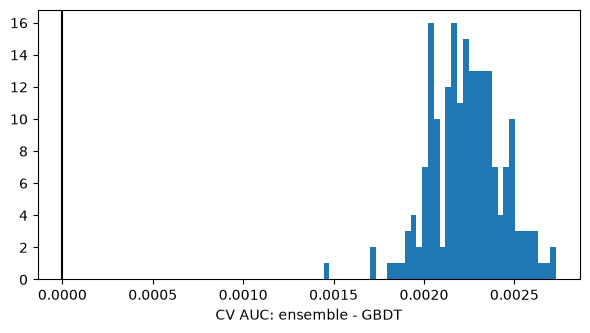

In [13]:
rng = np.random.default_rng(42)
block_rows = [np.flatnonzero(blocks == g) for g in range(4)]

diffs = []
for _ in range(200):
    d = []
    for rows_g in block_rows:
        i = rng.choice(rows_g, len(rows_g))
        d.append(roc_auc_score(y[i], ens_oof[i]) - roc_auc_score(y[i], gbdt_only[i]))
    diffs.append(np.mean(d))
diffs = np.array(diffs)

observed = cv_aucs[selected].mean() - cv_aucs["GBDT alone"].mean()
low, high = np.percentile(diffs, [2.5, 97.5])
print(f"ensemble - GBDT: {observed:+.4f}, 95% CI [{low:+.4f}, {high:+.4f}]")
print("ensemble wins in", (diffs > 0).mean(), "of resamples")

plt.figure(figsize=(7, 3.5))
plt.hist(diffs, bins=40)
plt.axvline(0, color="black")
plt.xlabel("CV AUC: ensemble - GBDT")
plt.show()

Yes: the ensemble wins in all 200 bootstrap samples.

## Summary

- The ensemble beats GBDT alone on CV (0.9367 vs 0.9345) in all 4 blocks.
- Separate weights per product overfit.